In [1]:
import numpy as np
import os
import scipy.stats as stats
import matplotlib.pyplot as pl
import math
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline
import glob

In [11]:
dir="/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/liuqian/fuxi-sr/vae_compression/"
#dir="Vg/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/liuqian/fuxi-sr/vae_based_temp_correct_split"
dir = "/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/liuqian/total_year_data/"
model = "cldas_GT"
#model = "t2m_vae_rec"
model_dir = os.path.join(dir,model)
model2 = "no_vae_path_total_test_set" 
#model2 = "v10m_vae_rec"
#model2 = "uv_vae"
#model2 = "no_vae_path_total_test_set"
model2_dir = os.path.join(dir,model2)
model3 = "vae_based_temp_correct_split"
model3_dir = os.path.join(dir,model3)
#time = "2021090900"
time_file = "2020050309_009.npy" #for reconstruction
file = os.path.join(model_dir,time_file)
file2 = os.path.join(model2_dir,time_file) #"rec",
file3 = os.path.join(model3_dir,time_file) 
data = np.load(file)
data2 = np.load(file2)
data3 = np.load(file3)

dt = data[:4000,:6000,2]
dt2 = data2[:4000,:6000,2]
dt3 = data3[:4000,:6000,0]

In [2]:
path = "/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/liuqian/total_year_data/cldas_GT"
files_path = os.path.join(path,"*001.npy")
files = glob.glob(files_path)
datetime_lt1 = [os.path.split(file)[1] for file in files]
models = ["cldas_GT","fuxi_resize_path","no_vae_path_total_test_set","256temp_vae","vae_based_temp_correct_split"]

In [4]:
model1 = "tempareture_20240827"
path_fuxi1 = os.path.join("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/liuqian/total_year_data/", model1)
files_fuxi1 = [os.path.join(path_fuxi1, datetime_file ) for datetime_file in datetime_lt1]
model1

'tempareture_20240827'

In [7]:
def abins_cal(image, npix=4000):
                        
    """
    image: the image input 
    npix: the pix length
    """
    fourier_image = np.fft.rfft(image, axis=-1, norm='forward')
    one_and_many_twos = np.concatenate(([1], [2] * (fourier_image.shape[-1] - 1)))
    fourier_amplitudes  = np.real(fourier_image  * np.conj(fourier_image)) * one_and_many_twos

    kfreq = np.fft.rfftfreq(npix) * npix
    #kfreq2D = np.meshgrid(kfreq, kfreq)
    #knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)
    #knrm = knrm.flatten()
    knrm = kfreq.flatten()
    fourier_amplitudes  = fourier_amplitudes.flatten()
    kbins = np.arange(0.5, npix//2+1, 25.)
    # kbins = np.arange(0.5, npix//2+1, 1.)

    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    Abins, _, _ = stats.binned_statistic(kfreq, fourier_amplitudes,
                                         statistic = "mean",
                                         bins = kbins)
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2) #total variance
    return Abins, kvals
    #return fourier_amplitudes, kfreq

    

In [8]:
# def cal_images(images):
#     abins_all = []
#     kvals_all= [] 
#     for img in images:
#         abins, kvals = abins_cal(img)
#         abins_all.append(abins)
#     abins_all_mean = np.mean(np.array(abins_all) , axis=0) 
#     return abins_all_mean, kvals
# 
abins_all = []
for file in files_fuxi1:
    a = 0
    try:
        data = np.load(file)
        dt = data[:4000,:6000,0]
        ilat_abins = []
        for i in range(0,4000,10):
            abins, kvals = abins_cal(dt[i,:],6000)
            ilat_abins.append(abins)
        #print("shape ",np.array(ilat_abins).shape )
        abins_all.append(np.mean(np.array(ilat_abins),axis=0))
    except :
        print("file not exit",file)
        a = a + 1

abins_all_mean = np.mean(np.array(abins_all) , axis=0) 


file not exit /cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/liuqian/total_year_data/tempareture_20240827/2020070113_001.npy


In [9]:
model1

'tempareture_20240827'

In [15]:
# abins_all_mean

In [11]:
np.save("ps_lt01_{}_t2m.npy".format(model1),abins_all_mean)

In [13]:
#Abins0 = np.load("ps_lt01_cldas_GT_u.npy")

#Abins2 = np.load("ps_lt01_no_vae_path_total_test_set_u.npy")
Abins0 = np.load("ps_lt01_cldas_GT_t2m.npy")
#Abins0 = np.load("ps_lt01_cldas_GT_u.npy")
Abins1 = np.load("ps_lt01_fuxi_resize_path_t2m.npy")
# Abins1 = np.load("ps_lt01_fuxi_resize_path_t2m.npy")
Abins2 = np.load("ps_lt01_no_vae_path_total_test_set_t2m.npy")
#Abins3 = np.load("ps_lt01_258temp_vae_t2m.npy") 
Abins3 = np.load("ps_lt01_tempareture_20240827_t2m.npy") 
# Abins4 = np.load("ps_lt01_vae_based_temp_correct_split_t2m.npy")
# Abins, kvals = abins_cal(dt[0,:],6000)
# Abins2, kvals2 = abins_cal(dt2[0,:],6000)
# Abins3, kvals3 = abins_cal(dt3[0,:],6000)

In [7]:
Abins0-Abins00

array([10.37831828, -1.6647946 , -4.47477372, -4.44776511, -3.99048093,
       -2.75693242, -1.50874825, -0.45707005, -0.14677438, -0.14111672,
       -0.18870005, -0.2011266 , -0.28601488, -0.33967409, -0.28637866,
       -0.21124776, -0.16033857, -0.1423392 , -0.13271178, -0.12805429,
       -0.12145198, -0.11809232, -0.1249073 , -0.13470326, -0.13489943,
       -0.12331936, -0.10509734, -0.09422134, -0.09110993, -0.08881702,
       -0.08745998, -0.0917135 , -0.09522962, -0.09144019, -0.08401996,
       -0.07719307, -0.07441621, -0.07152106, -0.07022275, -0.06863073,
       -0.06748472, -0.06767255, -0.06912779, -0.06905275, -0.06752461,
       -0.06371211, -0.06078546, -0.05960792, -0.05855733, -0.0580924 ,
       -0.058597  , -0.0599502 , -0.05903291, -0.05695626, -0.05480913,
       -0.05351201, -0.05261182, -0.05183819, -0.05137291, -0.05110102,
       -0.05105163, -0.05140522, -0.05182372, -0.05158477, -0.05014861,
       -0.04914926, -0.04845997, -0.04817382, -0.04801494, -0.04

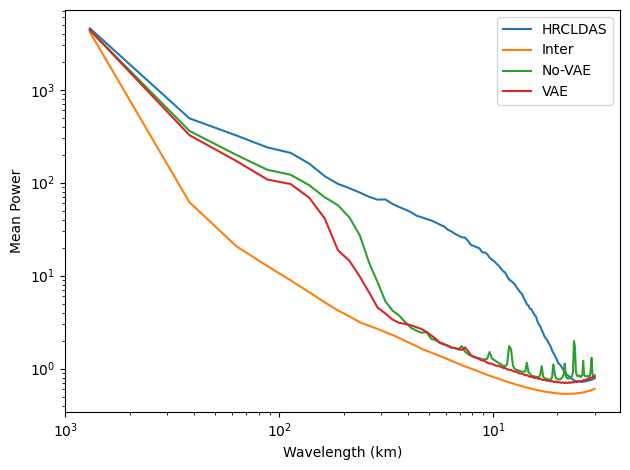

In [15]:
fig, ax = plt.subplots()
# pl.loglog(kvals, Abins, label = "HRCLDAS")
pl.loglog(kvals, Abins0, label = "HRCLDAS")
pl.loglog(kvals, Abins1, label = "Inter")
pl.loglog(kvals, Abins2, label = "No-VAE")
pl.loglog(kvals, Abins3, label = "VAE")
xtick = [10, 100, 1000]
xtick_label = ['$\mathrm{10^3}$', '$\mathrm{10^2}$', '$\mathrm{10^1}$']
ax.set_xticks(xtick, xtick_label, fontsize=10)
# pl.loglog(kvals, Abins4, label = "VAE_v1")
# pl.loglog(kvals_all_fcst_step80[:78],abins_all_fcst_step80[:78], label = "Diffusion step80")
# pl.loglog(kvals_all_fcst_notop[:78], abins_all_fcst_notop[:78], label = "Diffusion step200")
# # pl.loglog(kvals_all_fcst_step100[:78], abins_all_fcst_step100[:78], label = "Diffusion step100")
# #pl.loglog(kvals_all_fcst_step150[:78], abins_all_fcst_step150[:78], label = "Diffusion step150")
# pl.loglog(kvals_all_fcst_step250[:78], abins_all_fcst_step250[:78], label = "Diffusion step250")
# pl.loglog(kvals_all_fcst_step300[:78], abins_all_fcst_step300[:78], label = "Diffusion step300")
# #pl.loglog(kvals_all_wgan[:78], abins_all_wgan[:78], label = "GAN") #wwihtout topicgraph
#pl.loglog(kvals_all_unet[:78], abins_all_unet[:78], label = "U-Net") 
#pl.loglog(kvals_wgan, Abins_wgan)
pl.xlabel("Wavelength (km)")
pl.ylabel("Mean Power")
pl.tight_layout()
plt.legend()
plt.show()
#pl.savefig("M7_diffusion_steps_cloud_power_spectrum.png", dpi = 300, bbox_inches = "tight")

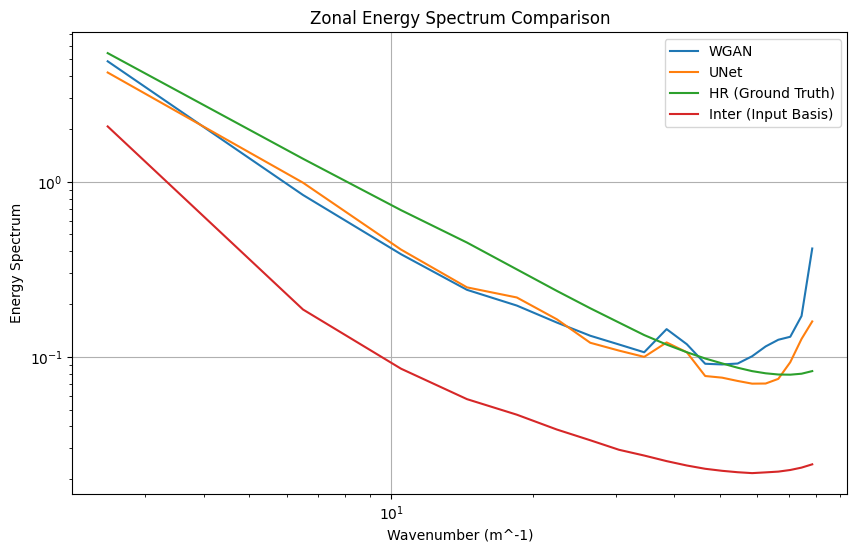

In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats


def calculate_zonal_energy_spectrum(data, npix):

    fourier_image = np.fft.rfft(data, axis=-1, norm='forward')
    # Adjust the power spectrum to account for both positive and negative frequencies
    one_and_many_twos = np.concatenate(([1], [2] * (fourier_image.shape[-1] - 1)))
    power_spectrum = np.real(fourier_image  * np.conj(fourier_image))* one_and_many_twos

    # Averaging the power spectra across all longitudes
    power_spectrum_mean = np.mean(power_spectrum, axis=0)

    # Setup the frequency bins
    kfreq = np.fft.rfftfreq(npix) * npix
    kbins = np.arange(0.5, npix//2+1, 4)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])

    # Bin the power spectrum
    Abins = stats.binned_statistic(kfreq, power_spectrum_mean, bins=kbins, statistic="mean")[0]
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)  # Normalize to get energy

    return Abins, kvals

# Load datasets
ds_wgan = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_onestepwgan_cri5_181_025_weightmae_aheadtop_0.008_130epoch/prcp_downs_wgan_year_2020.nc")
ds_unet = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex14_onestep_weightmae_aheadtop_0.008/prcp_downs_unet_year_2020.nc")
# xianzaishi10400
# Process all time steps and average the spectra
def average_zonal_spectra(ds, var):
    npix = ds.dims['lat']  
    spectra = []
    for i in range(ds.dims['time']):
        data = ds[var].isel(time=i).values
        Abins, kvals = calculate_zonal_energy_spectrum(data, npix)
        spectra.append(Abins)
    average_spectrum = np.mean(spectra, axis=0)
    return average_spectrum, kvals

avg_spectrum_wgan, kvals = average_zonal_spectra(ds_wgan, 'fcst')
avg_spectrum_unet, _ = average_zonal_spectra(ds_unet, 'fcst')
avg_spectrum_hr, _ = average_zonal_spectra(ds_wgan, 'hr')
avg_spectrum_inter, _ = average_zonal_spectra(ds_wgan, 'inter') 

# Plot the results
plt.figure(figsize=(10, 6))
plt.loglog(kvals, avg_spectrum_wgan, label='WGAN')
plt.loglog(kvals, avg_spectrum_unet, label='UNet')
plt.loglog(kvals, avg_spectrum_hr, label='HR (Ground Truth)')
plt.loglog(kvals, avg_spectrum_inter, label='Inter (Input Basis)')
plt.xlabel('Wavenumber (m^-1)')
plt.ylabel('Energy Spectrum')
plt.title('Zonal Energy Spectrum Comparison')
plt.legend()
plt.grid(True)
plt.show()


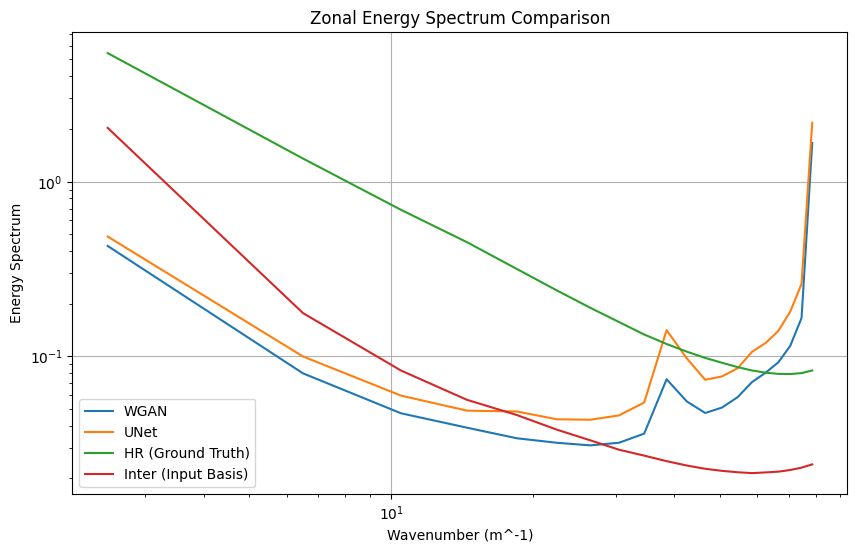

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats


def calculate_zonal_energy_spectrum(data, npix):

    fourier_image = np.fft.rfft(data, axis=-1, norm='forward')
    # Adjust the power spectrum to account for both positive and negative frequencies
    one_and_many_twos = np.concatenate(([1], [2] * (fourier_image.shape[-1] - 1)))
    power_spectrum = np.real(fourier_image  * np.conj(fourier_image))* one_and_many_twos

    # Averaging the power spectra across all longitudes
    power_spectrum_mean = np.mean(power_spectrum, axis=0)

    # Setup the frequency bins
    kfreq = np.fft.rfftfreq(npix) * npix
    kbins = np.arange(0.5, npix//2+1, 4)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])

    # Bin the power spectrum
    Abins = stats.binned_statistic(kfreq, power_spectrum_mean, bins=kbins, statistic="mean")[0]
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)  # Normalize to get energy

    return Abins, kvals

# Load datasets
ds_wgan = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_5_onestepwgan_cri5_1500_025_l1_aheadtop_10_180epoch/prcp_downs_wgan_year_2020.nc")
ds_unet = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_3_onestepwgan_cri5_181_025_l1_aheadtop_10_180epoch/prcp_downs_wgan_year_2020.nc")
# xianzaishi10400
# Process all time steps and average the spectra
def average_zonal_spectra(ds, var):
    npix = ds.dims['lat']  
    spectra = []
    for i in range(ds.dims['time']):
        data = ds[var].isel(time=i).values
        Abins, kvals = calculate_zonal_energy_spectrum(data, npix)
        spectra.append(Abins)
    average_spectrum = np.mean(spectra, axis=0)
    return average_spectrum, kvals

avg_spectrum_wgan, kvals = average_zonal_spectra(ds_wgan, 'fcst')
avg_spectrum_unet, _ = average_zonal_spectra(ds_unet, 'fcst')
avg_spectrum_hr, _ = average_zonal_spectra(ds_wgan, 'hr')
avg_spectrum_inter, _ = average_zonal_spectra(ds_wgan, 'inter') 

# Plot the results
plt.figure(figsize=(10, 6))
plt.loglog(kvals, avg_spectrum_wgan, label='WGAN')
plt.loglog(kvals, avg_spectrum_unet, label='UNet')
plt.loglog(kvals, avg_spectrum_hr, label='HR (Ground Truth)')
plt.loglog(kvals, avg_spectrum_inter, label='Inter (Input Basis)')
plt.xlabel('Wavenumber (m^-1)')
plt.ylabel('Energy Spectrum')
plt.title('Zonal Energy Spectrum Comparison')
plt.legend()
plt.grid(True)
plt.show()


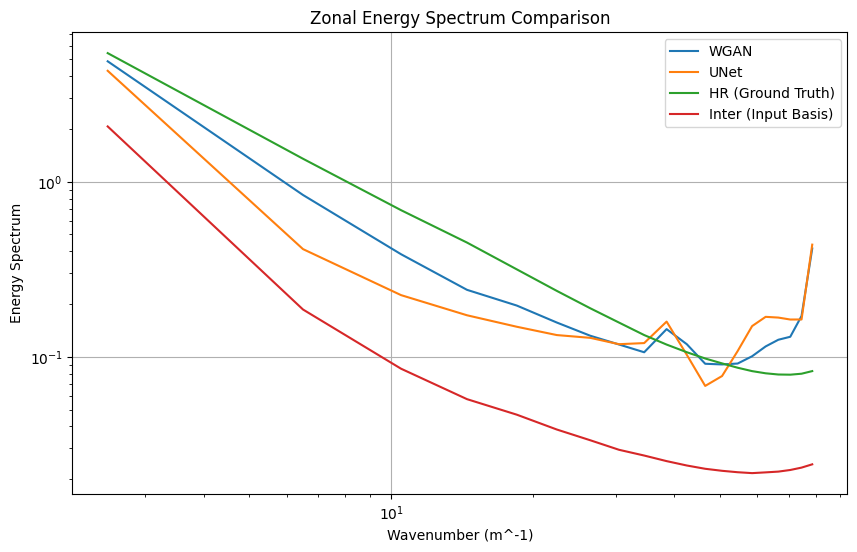

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats


def calculate_zonal_energy_spectrum(data, npix):

    fourier_image = np.fft.rfft(data, axis=-1, norm='forward')
    # Adjust the power spectrum to account for both positive and negative frequencies
    one_and_many_twos = np.concatenate(([1], [2] * (fourier_image.shape[-1] - 1)))
    power_spectrum = np.real(fourier_image  * np.conj(fourier_image))* one_and_many_twos

    # Averaging the power spectra across all longitudes
    power_spectrum_mean = np.mean(power_spectrum, axis=0)

    # Setup the frequency bins
    kfreq = np.fft.rfftfreq(npix) * npix
    kbins = np.arange(0.5, npix//2+1, 4)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])

    # Bin the power spectrum
    Abins = stats.binned_statistic(kfreq, power_spectrum_mean, bins=kbins, statistic="mean")[0]
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)  # Normalize to get energy

    return Abins, kvals

# Load datasets
ds_wgan = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_onestepwgan_cri5_181_025_weightmae_aheadtop_0.008_130epoch/prcp_downs_wgan_year_2020.nc")
ds_unet = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex17_onestepwgan_weightmae_aheadtop_0.008/prcp_downs_wgan_year_2020.nc")
# xianzaishi10400
# Process all time steps and average the spectra
def average_zonal_spectra(ds, var):
    npix = ds.dims['lat']  
    spectra = []
    for i in range(ds.dims['time']):
        data = ds[var].isel(time=i).values
        Abins, kvals = calculate_zonal_energy_spectrum(data, npix)
        spectra.append(Abins)
    average_spectrum = np.mean(spectra, axis=0)
    return average_spectrum, kvals

avg_spectrum_wgan, kvals = average_zonal_spectra(ds_wgan, 'fcst')
avg_spectrum_unet, _ = average_zonal_spectra(ds_unet, 'fcst')
avg_spectrum_hr, _ = average_zonal_spectra(ds_wgan, 'hr')
avg_spectrum_inter, _ = average_zonal_spectra(ds_wgan, 'inter') 

# Plot the results
plt.figure(figsize=(10, 6))
plt.loglog(kvals, avg_spectrum_wgan, label='WGAN')
plt.loglog(kvals, avg_spectrum_unet, label='UNet')
plt.loglog(kvals, avg_spectrum_hr, label='HR (Ground Truth)')
plt.loglog(kvals, avg_spectrum_inter, label='Inter (Input Basis)')
plt.xlabel('Wavenumber (m^-1)')
plt.ylabel('Energy Spectrum')
plt.title('Zonal Energy Spectrum Comparison')
plt.legend()
plt.grid(True)
plt.show()


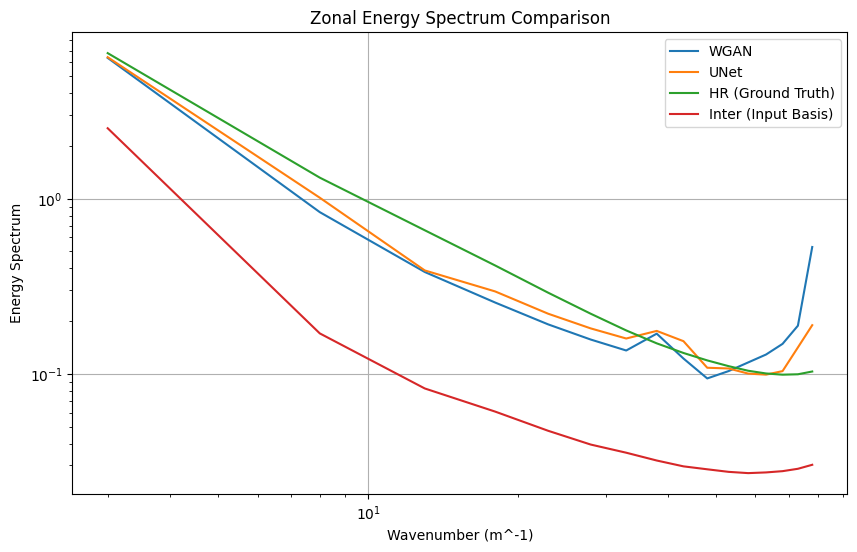

In [13]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats



def calculate_zonal_energy_spectrum(data, npix):
    """
    Calculate the zonal energy spectrum along latitude.
    
    Args:
    data (numpy.ndarray): 2D data array (latitude x longitude).
    npix (int): Number of points in latitude.
    
    Returns:
    Abins (numpy.ndarray): Radial mean of power spectrum.
    kvals (numpy.ndarray): Midpoint of bins used for the radial mean.
    """
    # Perform FFT along latitude (axis=0) and compute the power spectrum
    fourier_image = np.fft.rfft(data, axis=-1, norm='forward')
    
    # Adjust the power spectrum to account for both positive and negative frequencies
    one_and_many_twos = np.concatenate(([1], [2] * (fourier_image.shape[-1] - 1)))
    fourier_amplitudes = np.real(fourier_image * np.conj(fourier_image)) * one_and_many_twos

    # Calculate the frequency corresponding to the Fourier transform
    kfreq = np.fft.rfftfreq(npix) * npix
    # Flatten the kfreq and fourier_amplitudes for binning
    kfreq = kfreq.flatten()
    fourier_amplitudes = fourier_amplitudes.flatten()

    # Setup the frequency bins
    kbins = np.arange(0.5, npix // 2 + 1, 5)  # You can adjust the step size here as needed
    kvals = 0.5 * (kbins[1:] + kbins[:-1])  # Midpoints of the bins

    # Ensure that kfreq and fourier_amplitudes have the same length
    if len(kfreq) != len(fourier_amplitudes):
        raise ValueError(f"Length of kfreq ({len(kfreq)}) does not match length of fourier_amplitudes ({len(fourier_amplitudes)})")

    # Bin the power spectrum
    Abins, _, _ = stats.binned_statistic(kfreq, fourier_amplitudes,
                                         statistic="mean",
                                         bins=kbins)
    
    # Normalize the bins to calculate total energy
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)

    return Abins, kvals


# Load datasets
ds_wgan = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex23_onestepwgan_cri5_182_weightmae_aheadtop_0.008/prcp_downs_wgan_year_2020.nc")
ds_unet = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex14_onestep_weightmae_aheadtop_0.008/prcp_downs_unet_year_2020.nc")

def average_zonal_spectra(ds, var):
    npix = ds.dims['lat']  # Latitude size
    spectra = []
    for i in range(ds.dims['time']):
        data = ds[var].isel(time=i).values
        ilat_abins = []  
        
        for i in range(0, npix, 1):  
            ilat_data = data[i:i+1, :]  
            Abins, kvals = calculate_zonal_energy_spectrum(ilat_data, npix)
            ilat_abins.append(Abins)
            # print("shape ",np.array(ilat_abins).shape)
        
        # Calculate the average energy spectrum for this time step
        spectra.append(np.mean(ilat_abins, axis=0))
    
    average_spectrum = np.mean(spectra, axis=0)  # Average across all time steps
    return average_spectrum, kvals

avg_spectrum_wgan, kvals = average_zonal_spectra(ds_wgan, 'fcst')
avg_spectrum_unet, _ = average_zonal_spectra(ds_unet, 'fcst')
avg_spectrum_hr, _ = average_zonal_spectra(ds_wgan, 'hr')
avg_spectrum_inter, _ = average_zonal_spectra(ds_wgan, 'inter') 

# Plot the results
plt.figure(figsize=(10, 6))
plt.loglog(kvals, avg_spectrum_wgan, label='WGAN')
plt.loglog(kvals, avg_spectrum_unet, label='UNet')
plt.loglog(kvals, avg_spectrum_hr, label='HR (Ground Truth)')
plt.loglog(kvals, avg_spectrum_inter, label='Inter (Input Basis)')
plt.xlabel('Wavenumber (m^-1)')
plt.ylabel('Energy Spectrum')
plt.title('Zonal Energy Spectrum Comparison')
plt.legend()
plt.grid(True)
plt.show()
